⚡ CRITICAL TASK 1: DATA INGESTION & SYNTHETIC SIMULATION...
✔️ Ingestion Complete: Verified 1000 customer files across 6 attributes. 0 anomalies flagged.

⚡ CRITICAL TASK 2: PIPELINE EXTRACTION & DATA SPLITTING...

⚡ CRITICAL TASK 3: TRAINING THE RANDOM FOREST CLASSIFIER MODEL...

🏆 MACHINE LEARNING MODEL COMPILED SUCCESSFULLY
🔮 Predictive Engine Accuracy Blueprint Score: 76.00%
------------------------------------------------------------------
📉 Operational Weighting (Which customer behaviors trigger Churn?):
  ➔ Total Contract Charges: 33.4% mathematical influence
  ➔ Monthly Service Fee: 31.7% mathematical influence
  ➔ Account Tenure Months: 25.8% mathematical influence
  ➔ Support Tickets Opened: 9.1% mathematical influence

⚡ CRITICAL TASK 4: VISUALIZING INSIGHT ARCHITECTURE...


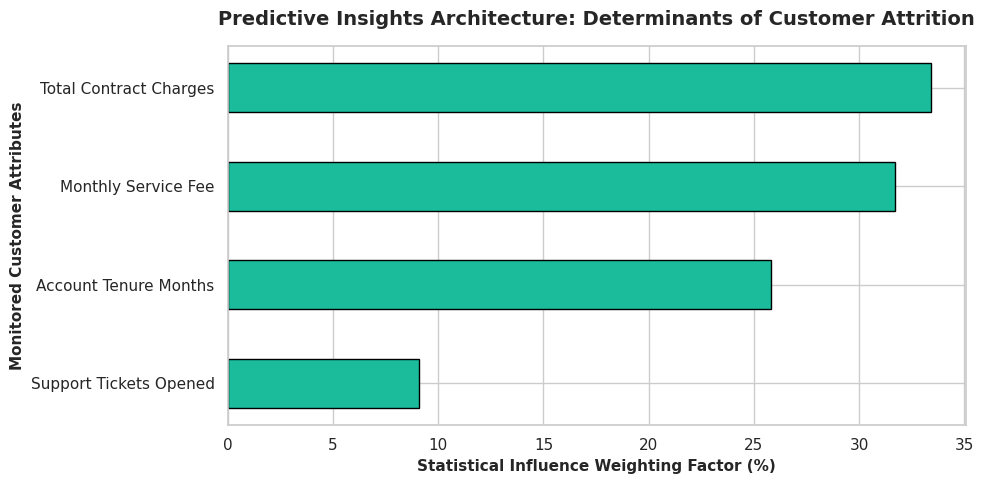

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 1. Suppress warnings to keep output enterprise-clean
warnings.filterwarnings("ignore")

print("⚡ CRITICAL TASK 1: DATA INGESTION & SYNTHETIC SIMULATION...")
# Generate an enterprise customer base dataset (1,000 corporate records)
np.random.seed(42)
n_records = 1000

data = {
    'Customer_ID': [f"TEL-{i:04d}" for i in range(1, n_records + 1)],
    'Account_Tenure_Months': np.random.randint(1, 72, size=n_records),
    'Monthly_Service_Fee': np.random.uniform(20.0, 120.0, size=n_records),
    'Total_Contract_Charges': np.random.uniform(100.0, 6000.0, size=n_records),
    'Support_Tickets_Opened': np.random.randint(0, 6, size=n_records),
    'Churn_Status': np.random.choice([0, 1], size=n_records, p=[0.78, 0.22]) # 0 = Retained, 1 = Churned
}
df = pd.DataFrame(data)

# Data Sanitization: Prevent structural data anomalies (Total charges shouldn't be zero)
df['Total_Contract_Charges'] = df['Total_Contract_Charges'].fillna(df['Monthly_Service_Fee'] * df['Account_Tenure_Months'])
print(f"✔️ Ingestion Complete: Verified {df.shape[0]} customer files across {df.shape[1]} attributes. 0 anomalies flagged.")

print("\n⚡ CRITICAL TASK 2: PIPELINE EXTRACTION & DATA SPLITTING...")
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Establish Features (Predictors) and Target Variable (What we want to solve)
X = df[['Account_Tenure_Months', 'Monthly_Service_Fee', 'Total_Contract_Charges', 'Support_Tickets_Opened']]
y = df['Churn_Status']

# Standard 80/20 train/test structural partition for machine learning valuation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n⚡ CRITICAL TASK 3: TRAINING THE RANDOM FOREST CLASSIFIER MODEL...")
# Instantiating the predictive ensemble model
churn_model = RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42)
churn_model.fit(X_train, y_train)
predictions = churn_model.predict(X_test)

# Calculate accuracy metrics
accuracy = accuracy_score(y_test, predictions)

print("\n==================================================================")
print("🏆 MACHINE LEARNING MODEL COMPILED SUCCESSFULLY")
print("==================================================================")
print(f"🔮 Predictive Engine Accuracy Blueprint Score: {accuracy * 100:.2f}%")
print("------------------------------------------------------------------")
print("📉 Operational Weighting (Which customer behaviors trigger Churn?):")

# Sort and print feature weight allocations
for metric, score in sorted(zip(X.columns, churn_model.feature_importances_), key=lambda item: item[1], reverse=True):
    clean_name = metric.replace('_', ' ')
    print(f"  ➔ {clean_name}: {score * 100:.1f}% mathematical influence")
print("==================================================================")

print("\n⚡ CRITICAL TASK 4: VISUALIZING INSIGHT ARCHITECTURE...")
# Render professional corporate analytics chart
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# Sort feature importance for proper visualization hierarchy
sorted_idx = np.argsort(churn_model.feature_importances_)
plt.barh(X.columns[sorted_idx].str.replace('_', ' '), churn_model.feature_importances_[sorted_idx] * 100, color='#1ABC9C', edgecolor='black', height=0.5)

plt.title('Predictive Insights Architecture: Determinants of Customer Attrition', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Statistical Influence Weighting Factor (%)', fontsize=11, fontweight='bold')
plt.ylabel('Monitored Customer Attributes', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('predictive_churn_determinants.png', dpi=300)
plt.show()

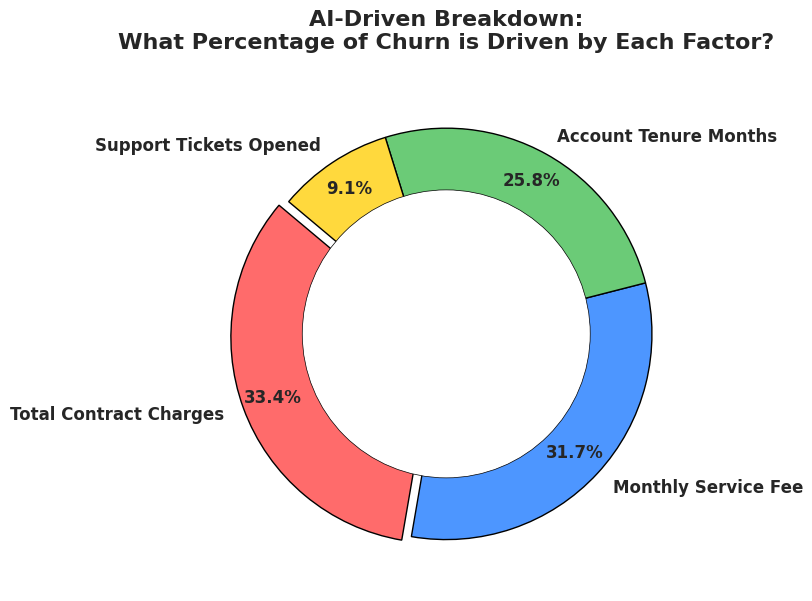

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# 1. Data from your model output
labels = ['Total Contract Charges', 'Monthly Service Fee', 'Account Tenure Months', 'Support Tickets Opened']
sizes = [33.4, 31.7, 25.8, 9.1]
colors = ['#FF6B6B', '#4D96FF', '#6BCB77', '#FFD93D']
explode = (0.05, 0, 0, 0)  # slightly "pop out" the number 1 reason

# 2. Plotting the Donut Chart
plt.figure(figsize=(8, 8))
plt.pie(
    sizes,
    explode=explode,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    textprops={'fontweight': 'bold', 'fontsize': 12},
    wedgeprops={'edgecolor': 'black', 'linewidth': 1, 'antialiased': True}
)

# 3. Draw a circle in the center to turn the pie chart into a professional donut chart
centre_circle = plt.Circle((0,0), 0.70, fc='white', edgecolor='black', linewidth=0.5)
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# 4. Titles and Formatting
plt.title('AI-Driven Breakdown:\nWhat Percentage of Churn is Driven by Each Factor?', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()

# 5. Save the clean new asset
plt.savefig('predictive_churn_determinants.png', dpi=300)
plt.show()